<a href="https://colab.research.google.com/github/rajeev198886/SKS-Data-Science-Internship-2026/blob/main/Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Telco_Customer_Churn_Dataset.csv.csv to Telco_Customer_Churn_Dataset.csv (1).csv


In [3]:
data = pd.read_csv("Telco_Customer_Churn_Dataset.csv (1).csv")

data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
data["Tenure_Group"] = pd.cut(
    data["tenure"],
    bins=[0,12,24,48,72],
    labels=["0-1 Year","1-2 Years","2-4 Years","4-6 Years"]
)

data["Tenure_Group"].value_counts()

,count
Tenure_Group,
4-6 Years,2239
0-1 Year,2175
2-4 Years,1594
1-2 Years,1024


In [6]:
data["Charge_Group"] = pd.cut(
    data["MonthlyCharges"],
    bins=[0,35,70,120],
    labels=["Low","Medium","High"]
)

data["Charge_Group"].value_counts()

,count
Charge_Group,
High,3583
Low,1735
Medium,1725


In [7]:
data["Contract"].value_counts()

,count
Contract,
Month-to-month,3875
Two year,1695
One year,1473


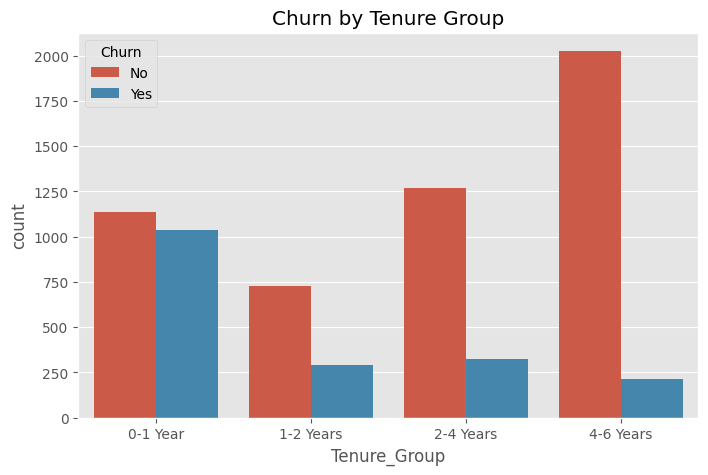

In [8]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Tenure_Group",
    hue="Churn",
    data=data
)

plt.title("Churn by Tenure Group")

plt.show()

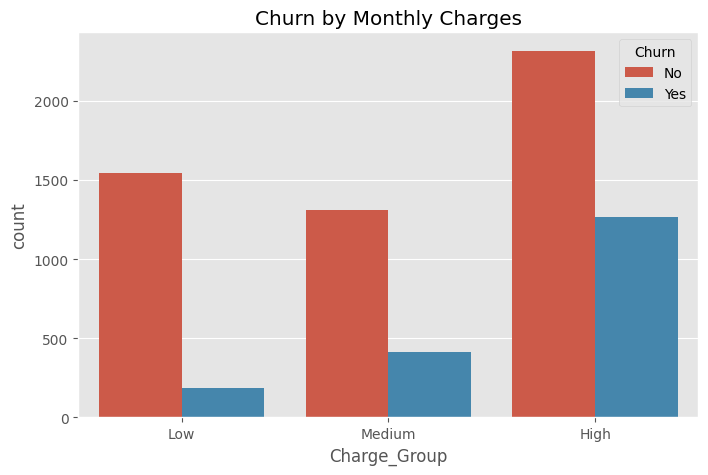

In [9]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Charge_Group",
    hue="Churn",
    data=data
)

plt.title("Churn by Monthly Charges")

plt.show()

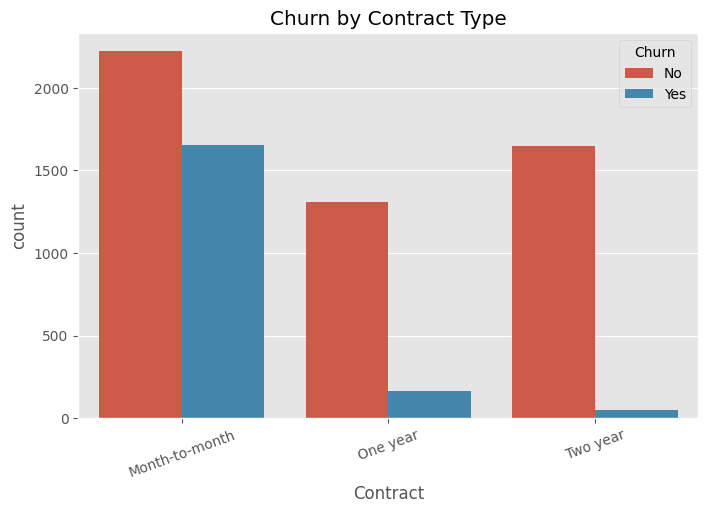

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Contract",
    hue="Churn",
    data=data
)

plt.title("Churn by Contract Type")

plt.xticks(rotation=20)

plt.show()

In [11]:
high_value = data[
    (data["MonthlyCharges"] > 70) &
    (data["tenure"] > 24)
]

high_value.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Tenure_Group,Charge_Group
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,2-4 Years,High
12,8091-TTVAX,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,Yes,Yes,One year,No,Credit card (automatic),100.35,5681.1,No,4-6 Years,High
13,0280-XJGEX,Male,0,No,No,49,Yes,Yes,Fiber optic,No,...,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,4-6 Years,High
14,5129-JLPIS,Male,0,No,No,25,Yes,No,Fiber optic,Yes,...,Yes,Yes,Month-to-month,Yes,Electronic check,105.50,2686.05,No,2-4 Years,High
15,3655-SNQYZ,Female,0,Yes,Yes,69,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Two year,No,Credit card (automatic),113.25,7895.15,No,4-6 Years,High


In [12]:
at_risk = high_value[
    high_value["Churn"]=="Yes"
]

at_risk.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Tenure_Group,Charge_Group
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,2-4 Years,High
13,0280-XJGEX,Male,0,No,No,49,Yes,Yes,Fiber optic,No,...,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,4-6 Years,High
26,6467-CHFZW,Male,0,Yes,Yes,47,Yes,Yes,Fiber optic,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,99.35,4749.15,Yes,2-4 Years,High
38,5380-WJKOV,Male,0,No,No,34,Yes,Yes,Fiber optic,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,106.35,3549.25,Yes,2-4 Years,High
99,4598-XLKNJ,Female,1,Yes,No,25,Yes,No,Fiber optic,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,98.50,2514.5,Yes,2-4 Years,High


In [13]:
print("High Value Customers :",len(high_value))

print("High Value Customers likely to Churn :",len(at_risk))

High Value Customers : 2230
High Value Customers likely to Churn : 455


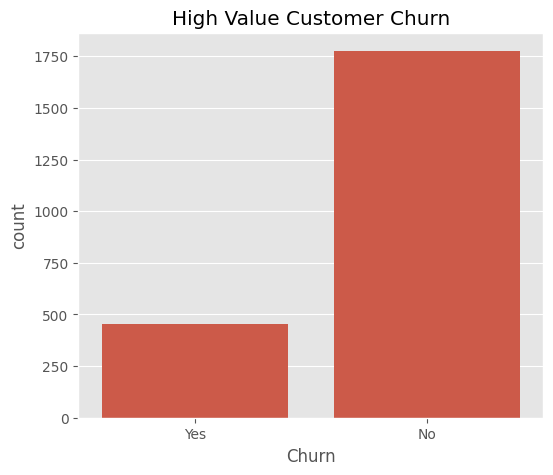

In [14]:
plt.figure(figsize=(6,5))

sns.countplot(
    x="Churn",
    data=high_value
)

plt.title("High Value Customer Churn")

plt.show()

In [15]:
data.groupby("Contract")["MonthlyCharges"].mean()

,MonthlyCharges
Contract,
Month-to-month,66.398490
One year,65.048608
Two year,60.770413


In [16]:
data.to_csv("Customer_Segmentation_Output.csv",index=False)

print("Segmented dataset saved successfully!")

Segmented dataset saved successfully!
